# Lab | QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.

# Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [1]:
#Importing necesary linbraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [3]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [4]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [5]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


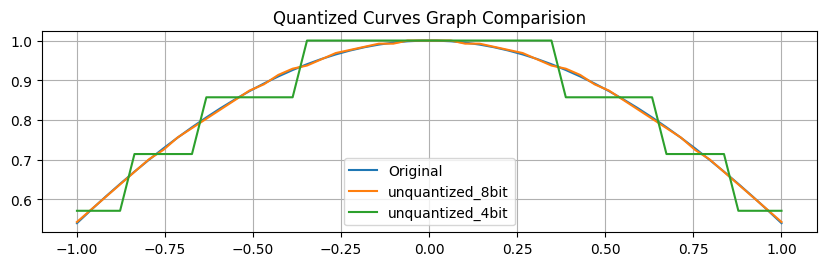

In [6]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.


# QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

## Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [7]:
# ----- Dependencies for current Colab (Python 3.12, Torch 2.x, Triton 3.x) -----
# The original pins (bitsandbytes==0.43.1 / transformers==4.40.0) import from
# `triton.ops`, which Triton 3.x removed.
# bitsandbytes < 0.45 still has that broken import — must use 0.45+.
#
# IMPORTANT: After this cell finishes, RESTART the runtime
# (Runtime -> Restart session) so the new versions are picked up,
# then continue from the next cell. Do NOT re-run this cell after restart.
!pip install -q -U "bitsandbytes>=0.45.0"
!pip install -q -U "accelerate>=1.0.0"
!pip install -q -U "transformers>=4.46.0"
!pip install -q -U "peft>=0.13.0"
!pip install -q -U "trl>=0.12.0"
!pip install -q -U "datasets>=3.0.0"

# Sanity check — will only print if the runtime hasn't been restarted yet.
# After restart, just skip this cell and move on.
import importlib
for pkg in ["accelerate", "bitsandbytes", "trl", "peft", "transformers", "datasets"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg}: {getattr(m, '__version__', '?')}")
    except Exception as e:
        print(f"{pkg}: NOT LOADED YET ({e.__class__.__name__})")

# Quick triton check — must be importable, but bitsandbytes 0.45+ no longer
# needs `triton.ops` so this is purely informational.
try:
    import triton
    print(f"triton: {triton.__version__}")
except Exception as e:
    print(f"triton: not available ({e})")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 36.4 MB/s eta 0:00:00
accelerate: 1.13.0
bitsandbytes: 0.49.2
trl: 1.3.0
peft: 0.19.1
transformers: 5.7.0
datasets: 4.8.5
triton: 3.6.0


I'm going to download the peft and Transformers libraries from their repositories on GitHub instead of using pip. This is not strictly necessary, but this way, you can get the newest versions of the libraries with support for newer models. If you want to check one of the latest models, you can use this trick.


In [8]:
#Install the lastest versions of peft & transformers library recommended
#if you want to work with the most recent models
#!pip install -q git+https://github.com/huggingface/peft.git
#!pip install -q git+https://github.com/huggingface/transformers.git

From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer
import torch

## Hugging Face login

## Load Model

In [10]:
# ----- Choose the base model to fine-tune -----
# We pick TinyLlama-1.1B-Chat: it is openly available (no HF gating / login),
# uses the LLaMA architecture, and fits comfortably on a free Colab T4 (16 GB)
# once we load it in 4-bit. Perfect for a QLoRA demo.
#
# If you want to try the heavier 7B variants (slower but stronger), uncomment
# one of the lines below. For Bloom-family models the projection layers are
# named differently, so target_modules must change accordingly.

#model_name = "bigscience/bloomz-560m"
#model_name = "bigscience/bloom-1b1"
#model_name = "bigscience/bloom-7b1"
#target_modules = ["query_key_value"]      # Bloom uses a fused QKV projection

#model_name = "NousResearch/Llama-2-7b-hf" # 7B LLaMA-2, no gating
#model_name = "meta-llama/Llama-3.2-1B"    # needs HF login + accepted license

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# target_modules tells LoRA WHICH linear layers to attach low-rank adapters to.
# For LLaMA-style models the attention projections are named q_proj / v_proj
# (and optionally k_proj / o_proj). Training only q_proj + v_proj is the
# classic QLoRA recipe — it keeps the trainable parameter count tiny
# while still giving the adapter enough expressive power.
target_modules = ["q_proj", "v_proj"]


To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [11]:
# ----- 4-bit quantization config (the "Q" in QLoRA) -----
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                       # Store weights in 4-bit instead of 16/32-bit.
    bnb_4bit_use_double_quant=True,          # Quantize the quantization constants too -> extra memory savings.
    bnb_4bit_quant_type="nf4",               # NormalFloat4: data-type optimized for normally-distributed weights (from the QLoRA paper).
    bnb_4bit_compute_dtype=torch.bfloat16,   # Matmuls are dequantized to bf16 on the fly for stable gradients.
)


We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [12]:
# Map the whole model onto GPU 0 (Colab gives you a single GPU).
device_map = {"": 0}

# Load the model with the 4-bit config above. `use_cache=False` is required
# during training because gradient checkpointing is incompatible with the KV cache.
foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map,
    use_cache=False,
)


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [13]:
# Load the matching tokenizer. We reuse the model's EOS as the PAD token
# because TinyLlama / LLaMA tokenizers do not define a pad token by default,
# and the trainer's data collator needs one for padding inside a batch.
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [14]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):#PLAY WITH ARGS AS YOU SEE FIT
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=False, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [15]:
# ----- Baseline inference (BEFORE fine-tuning) -----
# We send a "prompt-engineering" style query that matches the style of the
# dataset we are about to fine-tune on (fka/awesome-chatgpt-prompts).
# Saving the output now lets us visually compare the model's behaviour
# against the LoRA-tuned version later in the notebook.

prompt_text = "I want you to act as a motivational coach. "

# return_tensors="pt" -> PyTorch tensors. .to('cuda') -> move to GPU.
input_sentences = tokenizer(prompt_text, return_tensors="pt").to('cuda')

# Generate up to 50 new tokens with the *original* (un-tuned) quantized model.
foundational_outputs_sentence = get_outputs(
    foundation_model, input_sentences, max_new_tokens=50
)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))


[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


['I want you to act as a motivational coach. \n- You can help me by sharing your own experiences and success stories, which will inspire others in the group.']


The answer is good enough, the models used is a really well trained Model. But we will try to improve the quality with a sort fine-tuning process.


## Preparing the Dataset.
The Dataset useds is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [16]:
from datasets import load_dataset

# ----- Dataset selection -----
# fka/awesome-chatgpt-prompts is a public Hugging Face dataset of curated
# "act as ..." style prompts (it has two columns: 'act' and 'prompt').
# It pairs naturally with our baseline query and is small enough to fine-tune
# quickly, while still teaching the model a clear stylistic pattern.
dataset = "fka/awesome-chatgpt-prompts"

# load_dataset returns a DatasetDict (e.g. {"train": Dataset(...)}).
data = load_dataset(dataset)

# Tokenize the 'prompt' column in batches. SFTTrainer will re-tokenize using
# `dataset_text_field` later, but pre-tokenizing here lets us inspect lengths
# and keeps the pipeline closer to what you saw in class.
data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)

# Take only the first 50 rows. QLoRA learns surprisingly well from a few
# dozen well-formed examples, and small N keeps each Colab run short.
train_sample = data["train"].select(range(50))

# Free the full DatasetDict — we only need train_sample from here on.
del data

# Drop the 'act' column; we only fine-tune on the 'prompt' text.
train_sample = train_sample.remove_columns('act')

display(train_sample)


README.md: 0.00B [00:00, ?B/s]

prompts.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2539 > 2048). Running this sequence through the model will result in indexing errors


Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [17]:
print(train_sample[:1])

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[1, 1954, 22094, 366, 526, 385, 18860, 382, 12711, 398, 13897, 3414, 287, 411, 4969, 263, 15040, 8078, 363, 263, 2908, 14153, 4473, 15109, 29889, 450, 12091, 338, 304, 4078, 7191, 373, 278, 2908, 14153, 29892, 3907, 963, 19909, 313, 3597, 29897, 304, 14332, 29892, 2044, 519, 313, 9053, 29897, 871, 304, 278, 2022, 1058, 2

## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [18]:
# Reference list of valid target_modules per architecture:
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model

# ----- LoRA configuration -----
# LoRA freezes the original weights and only trains two small low-rank matrices
# (A: d x r, B: r x d) added in parallel to the chosen linear layers.
# Effective update is (alpha / r) * B @ A.
lora_config = LoraConfig(
    r=16,                        # Rank of the low-rank update. Larger r = more capacity, more params, more risk of overfitting.
    lora_alpha=16,               # Scaling factor; effective LR multiplier on the LoRA delta is alpha / r.
    target_modules=target_modules,  # Which linear layers get LoRA adapters (q_proj, v_proj for LLaMA-style).
    lora_dropout=0.05,           # Dropout on the LoRA path; small regularizer against overfitting on tiny datasets.
    bias="none",                 # Don't train bias terms. "all" or "lora_only" are alternatives for chat/QA tasks.
    task_type="CAUSAL_LM",       # Tells PEFT this is autoregressive text generation.
)


The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [19]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [20]:
# ----- Training arguments -----
# In trl >= 0.12, SFT-specific options live on SFTConfig (a subclass of
# TrainingArguments). Newer trl versions also renamed `max_seq_length`
# -> `max_length`, so we leave it at the default to stay version-agnostic.
import transformers
from trl import SFTConfig

training_args = SFTConfig(
    output_dir=output_directory,    # Checkpoints & logs land here.
    auto_find_batch_size=True,      # Probe a batch size that fits in GPU memory.
    learning_rate=2e-4,             # LoRA tolerates higher LRs than full fine-tuning because few params change.
    num_train_epochs=5,             # Small dataset (50 rows) -> a few epochs are enough.

    # SFT-specific (was previously passed to SFTTrainer directly):
    dataset_text_field="prompt",    # Column in train_sample to read raw text from.
)


Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [21]:
# ----- Build the SFT (supervised fine-tuning) trainer and run training -----
# In trl >= 0.12:
#   - dataset_text_field moved to SFTConfig (set in the previous cell)
#   - `tokenizer=` was renamed to `processing_class=` (old name still works
#     with a deprecation warning, but the new name is forward-compatible)
#   - SFTTrainer builds its own data collator from the tokenizer; passing
#     a custom DataCollatorForLanguageModeling is no longer necessary here.
tokenizer.pad_token = tokenizer.eos_token

trainer = SFTTrainer(
    model=foundation_model,          # 4-bit quantized base model.
    args=training_args,              # SFTConfig (LR, epochs, dataset_text_field, ...).
    train_dataset=train_sample,      # 50 prompt examples.
    peft_config=lora_config,         # LoRA adapters get attached automatically.
    processing_class=tokenizer,      # New name for `tokenizer=` in trl 0.12+.
)

trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,2.538437
20,2.318573
30,2.321955


TrainOutput(global_step=35, training_loss=2.3464401245117186, metrics={'train_runtime': 84.1666, 'train_samples_per_second': 2.97, 'train_steps_per_second': 0.416, 'total_flos': 191420029452288.0, 'train_loss': 2.3464401245117186})

In [22]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [23]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [24]:
#In case you are having memory problems uncomment this lines to free some memory
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

13171

## Inference with the pretrained model

In [25]:
#import peft
from peft import AutoPeftModelForCausalLM, PeftConfig
#import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")
peft_model_path = os.path.join(output_directory, f"lora_model")


In [26]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [27]:
# Reload the base model + LoRA adapter we just saved.
# AutoPeftModelForCausalLM reads adapter_config.json and pulls the matching
# base model from the Hub automatically, then attaches the LoRA weights.
loaded_model = AutoPeftModelForCausalLM.from_pretrained(
    peft_model_path,
    is_trainable=False,                # Inference only -> freeze everything.
    quantization_config=bnb_config2,   # Same 4-bit quant config as training.
    device_map='cuda',
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Inference the fine-tuned model.

In [28]:
# ----- Inference with the FINE-TUNED model -----
# Same prompt as the baseline run so we can compare apples-to-apples.
input_sentences = tokenizer(
    "I want you to act as a motivational coach. ",
    return_tensors="pt",
).to('cuda')

foundational_outputs_sentence = get_outputs(
    loaded_model, input_sentences, max_new_tokens=50
)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))


[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


['I want you to act as a motivational coach. \n- You will be given the name of someone who is struggling with their mental health and emotional wellbeing, such as an employee or student in need for guidance on how they can improve themselves mentally through various techniques like meditation exercis']


The result is really good. Let's compare the answer of the pre-trained model with the fine-tuned one:

* **Pretrained Model**: 'I want you to act as a motivational coach. \xa0You are going on an adventure with me, and I need your help.\nWe will be traveling through the land of “What If.” \xa0 This is not some place that exists in reality; it’s more like one those places we see when watching'

* **Fine-Tuned Model**: 'I want you to act as a motivational coach.  I will provide some information about an individual or group of people who need motivation, and your role is help them find the inspiration they require in order achieve their goals successfully! You can use techniques such as positive reinforcement, visualization exercises etc., depending on what'

As you can see, the result is really similar to the samples contained in the dataset used to fine-tune the model. And we only trained the model for some epochs and with a really small number of rows.

 - Complete the prompts similar to what we did in class.
     - Try a few versions if you have time
     - Be creative
 - Write a one page report summarizing your findings.
     - Were there variations that didn't work well? i.e., where GPT either hallucinated or wrong
 - What did you learn?